# Reproducing Stephen Dolan's GENIE/NuWro `W`-split $Q^2$ ratio plot

Both generators are bare NUISANCE generator-truth flat trees (`data/Generators/{GENIE,NuWro}/{fhc_Nu14,fhc_Nu-14}/`) -- no detector simulation or selection on either side, so the two are on equal footing.

- **CC-other proxy: `abs(Mode) > 3 & abs(Mode) < 30`** (CC resonance production, NEUT reaction-code convention) -- the selection Stephen Dolan used, confirmed via Jaesung. `Mode` needs `abs()`: it's signed, negative for the antineutrino (`fhc_Nu-14`) sample.
- **numu (`fhc_Nu14`) + numubar (`fhc_Nu-14`) combined**, weighted by `InputWeight * fScaleFactor` (`fScaleFactor` is a per-file constant that differs by species, so an unweighted row count would mis-weight the two).
- **Ratio is `R = NuWro/GENIE`**, raw per-bin weighted counts, no per-W-region normalization -- confirmed against Dolan's own numbers (via Jaesung): testing both directions on the "All W" curve, `NuWro/GENIE` reproduces his numbers and `GENIE/NuWro` does not.
- **Binning: 0-1.0 GeV$^2$ in 10 bins of 0.1 GeV$^2$.** Dolan's plot has an x-axis drawn 0-10 with points at half-integer positions, labeled "$Q^2$ (GeV$^2$)" -- reproducing it at a literal 0-10 GeV$^2$/1 GeV$^2$-bin binning does not match his numbers at all (checked directly). Treating his tick labels as bin index rather than physical Q$^2$ -- i.e. the true range is 0-1.0 GeV$^2$ -- matches his curve's shape and scale well. That points to his plot's x-axis being mislabeled, not this binning choice being wrong.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import uproot

ICARUS_ROOT = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS'
GENERATORS_DIR = f'{ICARUS_ROOT}/ICARUS_CC0pi_GUNDAM/data/Generators'

def open_with_retry(path, tries=5, sleep_s=2.0):
    # The Google-Drive-mounted files occasionally hit a transient FUSE-level
    # 'Resource deadlock avoided' OSError on first read -- retrying a few times
    # with a short sleep clears it.
    last_exc = None
    for _ in range(tries):
        try:
            return uproot.open(path)
        except OSError as exc:
            last_exc = exc
            time.sleep(sleep_s)
    raise last_exc


In [16]:
import glob

MODE_BRANCHES = ['InputWeight', 'fScaleFactor', 'W_nuc_rest', 'Q2_true', 'Mode']
Q2_EDGES_MODE = np.linspace(0.0, 1.0, 11)     # 10 bins, 0.1 GeV^2 each -- see binning note above
NBINS_MODE = len(Q2_EDGES_MODE) - 1
W_SPLIT_MEV_MODE = 1400.0

def load_species_weighted(base_dir, gen, species):
    # Glob for whatever files actually exist -- NuWro fhc_Nu-14 is missing
    # index 5 (never produced, not a download gap), so file indices are not
    # contiguous and must not be assumed via range(n_files).
    paths = sorted(glob.glob(f'{base_dir}/{gen}/{species}/output_{gen}_*.nuisflat.root'))
    if not paths:
        raise FileNotFoundError(f'{gen}/{species}: no files found under {base_dir}')

    h_all = np.zeros(NBINS_MODE)
    h_low = np.zeros(NBINS_MODE)
    h_high = np.zeros(NBINS_MODE)
    n_events = 0
    for path in paths:
        t = open_with_retry(path)['FlatTree_VARS']
        arrs = t.arrays(MODE_BRANCHES, library='np')
        w = arrs['InputWeight'].astype(np.float64) * arrs['fScaleFactor'].astype(np.float64)
        W = arrs['W_nuc_rest'].astype(np.float64)
        q2 = arrs['Q2_true'].astype(np.float64) / 1e6
        mode = np.abs(arrs['Mode'].astype(np.int64))   # abs() -- Mode is signed for antineutrino species
        ccres = (mode > 3) & (mode < 30)

        is_all = ccres & (W > 0) & np.isfinite(W)
        is_low = is_all & (W < W_SPLIT_MEV_MODE)
        is_high = ccres & (W >= W_SPLIT_MEV_MODE) & np.isfinite(W)

        in_range = (q2 >= 0.0) & (q2 < Q2_EDGES_MODE[-1])
        idx = np.clip(np.digitize(q2, Q2_EDGES_MODE) - 1, 0, NBINS_MODE - 1)

        for region_mask, harr in [(is_all, h_all), (is_low, h_low), (is_high, h_high)]:
            m = region_mask & in_range
            if not m.any():
                continue
            wsub, idxsub = w[m], idx[m]
            for b in range(NBINS_MODE):
                harr[b] += wsub[idxsub == b].sum()
        n_events += len(W)
    return h_all, h_low, h_high, n_events, len(paths)

mode_hists = {}
for gen in ['GENIE', 'NuWro']:
    h_all_tot = np.zeros(NBINS_MODE); h_low_tot = np.zeros(NBINS_MODE); h_high_tot = np.zeros(NBINS_MODE)
    n_tot = 0
    for species in ['fhc_Nu14', 'fhc_Nu-14']:
        h_all, h_low, h_high, n_events, n_files = load_species_weighted(GENERATORS_DIR, gen, species)
        h_all_tot += h_all; h_low_tot += h_low; h_high_tot += h_high
        n_tot += n_events
        print(f'  {gen}/{species}: {n_files} files, {n_events} events')
    mode_hists[gen] = dict(all=h_all_tot, low=h_low_tot, high=h_high_tot)
    print(f'{gen} total (numu+numubar): {n_tot} events\n')


  GENIE/fhc_Nu14: 10 files, 10000000 events
  GENIE/fhc_Nu-14: 10 files, 10000000 events
GENIE total (numu+numubar): 20000000 events

  NuWro/fhc_Nu14: 10 files, 10000000 events
  NuWro/fhc_Nu-14: 9 files, 9000000 events
NuWro total (numu+numubar): 19000000 events



All $W$ [1.3223 1.0987 0.9827 0.905  0.8519 0.8153 0.7847 0.766  0.7544 0.7477]
$W<1.4$ GeV [1.4395 1.3279 1.2804 1.2268 1.1726 1.131  1.0858 1.0533 1.0182 0.9803]
$W>1.4$ GeV [1.0412 0.7803 0.6864 0.6518 0.6402 0.6353 0.6332 0.6357 0.6432 0.6555]


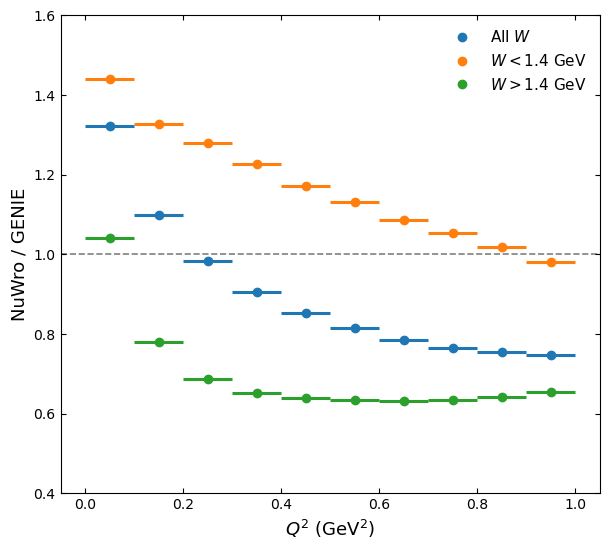

In [17]:
centers_mode = 0.5 * (Q2_EDGES_MODE[:-1] + Q2_EDGES_MODE[1:])
mode_colors = {'all': 'tab:blue', 'low': 'tab:orange', 'high': 'tab:green'}
mode_labels = {'all': 'All $W$', 'low': '$W<1.4$ GeV', 'high': '$W>1.4$ GeV'}

fig, ax = plt.subplots(figsize=(6.2, 5.6))
R_mode = {}
for region in ['all', 'low', 'high']:
    hG = mode_hists['GENIE'][region]
    hN = mode_hists['NuWro'][region]
    R = hN / hG   # confirmed-correct direction: NuWro/GENIE
    R_mode[region] = R
    for i in range(NBINS_MODE):
        ax.hlines(R[i], Q2_EDGES_MODE[i], Q2_EDGES_MODE[i + 1], color=mode_colors[region], lw=2.2)
    ax.plot(centers_mode, R, 'o', color=mode_colors[region], ms=6, label=mode_labels[region])

ax.axhline(1.0, color='gray', ls='--', lw=1.2, zorder=0)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.4, 1.6)
ax.set_xlabel(r'$Q^2$ (GeV$^2$)', fontsize=13)
ax.set_ylabel('NuWro / GENIE', fontsize=13)
ax.legend(loc='upper right', frameon=False, fontsize=11)
ax.tick_params(direction='in', top=True, right=True, which='both')
fig.tight_layout()

os.makedirs('genie_nuwro_plots', exist_ok=True)
fig.savefig('genie_nuwro_plots/genie_nuwro_ratio_mode_ccres.pdf', bbox_inches='tight')
fig.savefig('genie_nuwro_plots/genie_nuwro_ratio_mode_ccres.png', bbox_inches='tight', dpi=150)

for region in ['all', 'low', 'high']:
    print(mode_labels[region], np.round(R_mode[region], 4))
